# Componente 1 -- Ingenieria de datos y representacion de secuencias

Proyecto 2 -- CC3092 Deep Learning
Deteccion de lavado de dinero en remesas Guatemala-Estados Unidos.

Dataset: [PaySim](https://www.kaggle.com/datasets/ealaxi/paysim1), 6.3M transacciones sinteticas.

Se trabaja unicamente con PaySim: al examinar su estructura (Seccion 3) se encuentra que combinar las apariciones de una cuenta como origen y destino da suficiente historial transaccional para construir secuencias, sin necesitar el dataset complementario IBM AML.

El pipeline carga los datos por chunks y solo con las columnas necesarias en cada paso, en vez de materializar el CSV completo de una sola vez.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path

SEED = 42
rng = np.random.default_rng(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

DATA_RAW = Path("../data/raw")
DATA_PROCESSED = Path("../data/processed")
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

PAYSIM_PATH = DATA_RAW / "PS_20174392719_1491204439457_log.csv"
print("PaySim existe:", PAYSIM_PATH.exists())

PaySim existe: True


## 1. Carga liviana y calidad de datos

Se cargan solo las columnas necesarias para el control de calidad inicial (no el archivo completo).

In [2]:
df_meta = pd.read_csv(
    PAYSIM_PATH,
    usecols=["step", "type", "amount", "isFraud", "isFlaggedFraud"],
    dtype={"step": "int32", "type": "category", "amount": "float32", "isFraud": "int8", "isFlaggedFraud": "int8"},
)
print(f"Shape: {df_meta.shape}")
print(f"Memoria: {df_meta.memory_usage(deep=True).sum() / 1e6:.1f} MB")
df_meta.head()

Shape: (6362620, 5)
Memoria: 70.0 MB


,step,type,amount,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.639648,0,0
1,1,PAYMENT,1864.280029,0,0
2,1,TRANSFER,181.000000,1,0
3,1,CASH_OUT,181.000000,1,0
4,1,PAYMENT,11668.139648,0,0


In [3]:
print("Nulos por columna:")
print(df_meta.isnull().sum())
print(f"\nRango de step: {df_meta['step'].min()} - {df_meta['step'].max()} (1 step = 1 hora -> {df_meta['step'].max()/24:.1f} dias simulados)")
df_meta.describe()

Nulos por columna:
step              0
type              0
amount            0
isFraud           0
isFlaggedFraud    0
dtype: int64

Rango de step: 1 - 743 (1 step = 1 hora -> 31.0 dias simulados)


,step,amount,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,1.000000e+00,1.000000e+00


## 2. Exploracion: clases y tipos de transaccion

In [4]:
fraud_counts = df_meta["isFraud"].value_counts()
fraud_pct = df_meta["isFraud"].mean() * 100
print(fraud_counts)
print(f"\nProporcion de fraude: {fraud_pct:.4f}%")
print(f"Flagged por el sistema de reglas original: {df_meta['isFlaggedFraud'].sum()} de {df_meta['isFraud'].sum()} fraudes reales")

isFraud
0    6354407
1       8213
Name: count, dtype: int64

Proporcion de fraude: 0.1291%
Flagged por el sistema de reglas original: 16 de 8213 fraudes reales


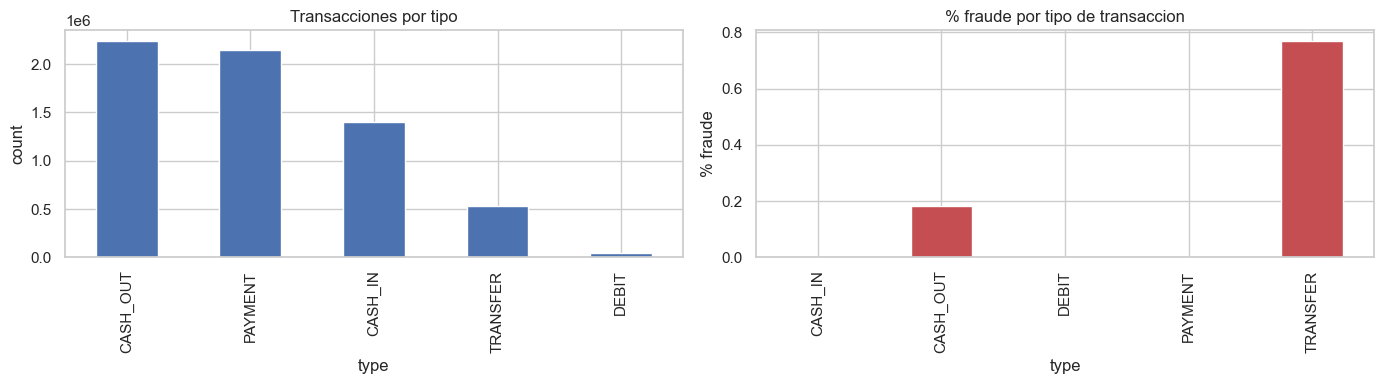

           sum    count       pct
type                             
CASH_IN      0  1399284  0.000000
CASH_OUT  4116  2237500  0.183955
DEBIT        0    41432  0.000000
PAYMENT      0  2151495  0.000000
TRANSFER  4097   532909  0.768799


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df_meta["type"].value_counts().plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Transacciones por tipo")
axes[0].set_ylabel("count")

fraud_by_type = df_meta.groupby("type", observed=True)["isFraud"].agg(["sum", "count"])
fraud_by_type["pct"] = fraud_by_type["sum"] / fraud_by_type["count"] * 100
fraud_by_type["pct"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("% fraude por tipo de transaccion")
axes[1].set_ylabel("% fraude")

plt.tight_layout()
plt.show()
print(fraud_by_type)

del df_meta  # ya no se necesita; liberar memoria

Hallazgo: el fraude en PaySim ocurre exclusivamente en TRANSFER y CASH_OUT, nunca en PAYMENT, CASH_IN o DEBIT.

## 3. Analisis de remitente vs. cuenta

El proyecto pide secuencias por remitente. Se verifica si nameOrig (remitente) tiene suficiente repeticion como para construir un historial temporal.

In [6]:
df_acc = pd.read_csv(
    PAYSIM_PATH,
    usecols=["nameOrig", "nameDest", "isFraud"],
    dtype={"nameOrig": "string", "nameDest": "string", "isFraud": "int8"},
)

orig_counts = df_acc["nameOrig"].value_counts()
print(f"Remitentes (nameOrig) unicos: {orig_counts.shape[0]:,} de {len(df_acc):,} transacciones")
print(orig_counts.describe())
print(f"Remitentes con >= 2 transacciones: {(orig_counts >= 2).sum():,} ({(orig_counts >= 2).mean()*100:.3f}%)")

Remitentes (nameOrig) unicos: 6,353,307 de 6,362,620 transacciones


count    6353307.0
mean      1.001466
std        0.03832
min            1.0
25%            1.0
50%            1.0
75%            1.0
max            3.0
Name: count, dtype: Float64
Remitentes con >= 2 transacciones: 9,298 (0.146%)


Resultado: 99.85% de los remitentes envia una sola vez en todo el dataset. No hay historial que capturar sobre nameOrig, asi que construir secuencias por remitente tal como pide el enunciado no es viable sobre esa columna: cada nameOrig es esencialmente un ID de transaccion, no un identificador de cliente persistente.

Se prueba entonces con la huella completa de la cuenta, la union de sus apariciones como origen y como destino. Es ademas la definicion correcta desde la perspectiva de un sistema AML real: lo que se monitorea es la cuenta, no el rol que jugo en una transaccion puntual.

In [7]:
dest_counts = df_acc["nameDest"].value_counts()
total_counts = orig_counts.add(dest_counts, fill_value=0)

print(f"Cuentas unicas totales (nameOrig U nameDest): {total_counts.shape[0]:,}")
print(total_counts.describe())
for k in [2, 5, 10, 20]:
    print(f"Cuentas con >= {k} apariciones totales: {(total_counts >= k).sum():,}")

Cuentas unicas totales (nameOrig U nameDest): 9,073,900


count    9073900.0
mean        1.4024
std       2.566607
min            1.0
25%            1.0
50%            1.0
75%            1.0
max          113.0
Name: count, dtype: Float64
Cuentas con >= 2 apariciones totales: 469,277
Cuentas con >= 5 apariciones totales: 280,347


Cuentas con >= 10 apariciones totales: 146,679
Cuentas con >= 20 apariciones totales: 48,262


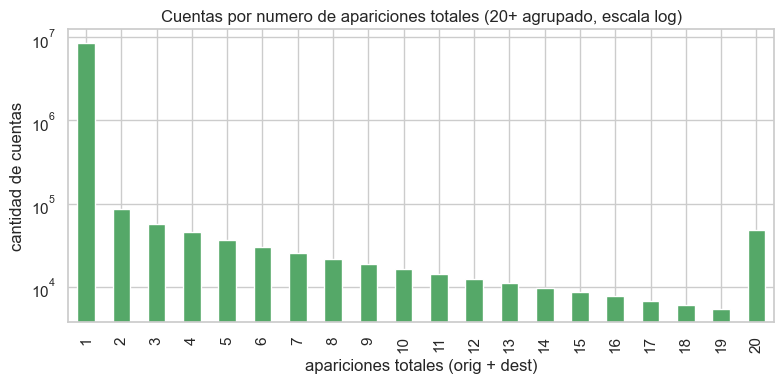

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
capped = total_counts.clip(upper=20)
capped.value_counts().sort_index().plot(kind="bar", ax=ax, color="#55A868")
ax.set_title("Cuentas por numero de apariciones totales (20+ agrupado, escala log)")
ax.set_xlabel("apariciones totales (orig + dest)")
ax.set_ylabel("cantidad de cuentas")
ax.set_yscale("log")
plt.tight_layout()
plt.show()

### 3.1 Patron de "cuenta mula": ¿el fraude preserva identidad de cuenta a lo largo del tiempo?

PaySim simula el fraude como pares TRANSFER (victima -> mula) seguido de CASH_OUT (mula retira el efectivo). Si la cuenta mula fuera un identificador persistente, el `nameDest` del TRANSFER deberia coincidir con el `nameOrig` del CASH_OUT correspondiente.

In [9]:
df_pat = pd.read_csv(
    PAYSIM_PATH,
    usecols=["step", "type", "amount", "nameOrig", "nameDest", "isFraud"],
    dtype={"step": "int32", "type": "category", "amount": "float32", "nameOrig": "string", "nameDest": "string", "isFraud": "int8"},
)
fraud = df_pat[df_pat["isFraud"] == 1]

transfers = fraud[fraud["type"] == "TRANSFER"][["step", "nameDest", "amount"]].rename(columns={"nameDest": "mule"})
cashouts = fraud[fraud["type"] == "CASH_OUT"][["step", "nameOrig", "amount"]].rename(columns={"nameOrig": "mule"})
same_account = transfers.merge(cashouts, on="mule", suffixes=("_t", "_c"))
print(f"Pares TRANSFER->CASH_OUT que comparten la MISMA cuenta mula: {len(same_account)} de {len(transfers)} transfers de fraude")

del df_pat  # liberar; se recarga filtrado mas adelante

Pares TRANSFER->CASH_OUT que comparten la MISMA cuenta mula: 0 de 4097 transfers de fraude


Confirmado: 0 pares comparten cuenta mula. El fraude en PaySim son eventos episodicos, sin identidad de cuenta que conecte el TRANSFER con el CASH_OUT que le sigue.

### 3.2 Decision de diseno: unidad de analisis = cuenta, no remitente

Se redefine la unidad de secuencia de remitente a cuenta (nameOrig union nameDest). La huella completa de cuenta si tiene estructura temporal, y es la definicion correcta desde la perspectiva de negocio: un oficial de cumplimiento monitorea una cuenta, no su rol puntual en una transaccion. Como el fraude no preserva identidad de cuenta mula (Seccion 3.1), la senal que el sistema puede aprender no es que una cuenta se volvio mula, sino que una transaccion no encaja con el patron normal del resto de su historia, que es el objetivo de un autoencoder de reconstruccion (Etapa A, Componente 2).

Esta limitacion del dataset se retoma en el reporte ejecutivo.

## 4. Decisiones de diseno del pipeline

Subconjunto de cuentas. De 469,277 cuentas con 2 o mas apariciones, solo 5,529 tienen fraude. Se usan todas las cuentas con fraude (5,529, sin descartar ningun positivo) mas una muestra aleatoria de 100,000 cuentas normales, semilla fija 42. Da una proporcion cercana a 20:1, suficiente para que la Etapa A aprenda normalidad a buena escala.

Longitud minima de secuencia. Se excluyen cuentas con 1 sola aparicion: no hay una segunda observacion contra la cual comparar, asi que un modelo secuencial no tiene nada que aprender ahi. Necesitarian un detector complementario a nivel de transaccion individual.

Features por evento:
- log_amount: log1p(amount) estandarizado con z-score de train, por la asimetria tipica de los montos.
- type_code: tipo de transaccion como indice de nn.Embedding.
- direction: saliente o entrante.
- hour_sin, hour_cos: codificacion ciclica de la hora, para capturar concentracion horaria.
- delta_t: horas desde la transaccion anterior de la cuenta, indicador de frecuencia o rafagas.
- frac_balance: fraccion del balance que mueve la transaccion, indicador de vaciado de cuenta.
- near_threshold: monto en [8000, 10000), justo debajo del umbral de reporte obligatorio, indicador de estructuracion.

Todas las features se estandarizan solo con estadisticas de train, para evitar fuga de datos.

Balanceo de clases. Se maneja en dos niveles: el submuestreo de cuentas normales de arriba en este notebook, y la funcion de perdida ponderada de la Etapa B, justificada en el notebook del Componente 2.

Splits sin fuga de datos. El split train/val/test se hace a nivel de cuenta, no de transaccion, para que ninguna cuenta aparezca en mas de un split. 70/15/15, estratificado por has_fraud, semilla fija.

## 5. Construccion del pipeline

### 5.1 Seleccion de cuentas

In [10]:
fraud_involved = pd.concat([fraud["nameOrig"], fraud["nameDest"]]).unique()
fraud_multi = set(total_counts.loc[total_counts.index.isin(fraud_involved) & (total_counts >= 2)].index)

normal_multi = total_counts[(total_counts >= 2) & (~total_counts.index.isin(fraud_involved))].index
normal_sample = set(rng.choice(normal_multi, size=100_000, replace=False))

selected_accounts = fraud_multi | normal_sample
print(f"Cuentas fraude con historial (>=2): {len(fraud_multi):,}")
print(f"Muestra de cuentas normales: {len(normal_sample):,}")
print(f"Total cuentas seleccionadas: {len(selected_accounts):,}")

del df_acc, orig_counts, dest_counts  # liberar memoria

Cuentas fraude con historial (>=2): 5,529
Muestra de cuentas normales: 100,000
Total cuentas seleccionadas: 105,529


### 5.2 Carga filtrada por chunks

El CSV se lee en chunks y solo se conservan las filas donde alguna de las dos cuentas esta en selected_accounts.

In [11]:
dtypes_full = {
    "step": "int32", "type": "category", "amount": "float32",
    "nameOrig": "string", "oldbalanceOrg": "float32", "newbalanceOrig": "float32",
    "nameDest": "string", "oldbalanceDest": "float32", "newbalanceDest": "float32",
    "isFraud": "int8", "isFlaggedFraud": "int8",
}

chunks = []
for chunk in pd.read_csv(PAYSIM_PATH, dtype=dtypes_full, chunksize=500_000):
    mask = chunk["nameOrig"].isin(selected_accounts) | chunk["nameDest"].isin(selected_accounts)
    if mask.any():
        chunks.append(chunk.loc[mask])

filtered = pd.concat(chunks, ignore_index=True)
del chunks
print(f"Filas filtradas: {filtered.shape[0]:,} de 6,362,620 ({filtered.shape[0]/6_362_620*100:.1f}%)")
print(f"Memoria: {filtered.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Filas filtradas: 943,608 de 6,362,620 (14.8%)


Memoria: 152.8 MB


### 5.3 Construccion de eventos por cuenta

Cada transaccion genera hasta 2 eventos: uno de salida para su nameOrig y uno de entrada para su nameDest, si estan seleccionadas.

In [12]:
TYPE_CODES = {"CASH_IN": 0, "CASH_OUT": 1, "DEBIT": 2, "PAYMENT": 3, "TRANSFER": 4}

out_mask = filtered["nameOrig"].isin(selected_accounts)
events_out = filtered.loc[out_mask, ["step", "type", "amount", "nameOrig", "oldbalanceOrg", "isFraud"]].copy()
events_out = events_out.rename(columns={"nameOrig": "account", "oldbalanceOrg": "ref_balance"})
events_out["direction"] = 0

in_mask = filtered["nameDest"].isin(selected_accounts)
events_in = filtered.loc[in_mask, ["step", "type", "amount", "nameDest", "oldbalanceDest", "isFraud"]].copy()
events_in = events_in.rename(columns={"nameDest": "account", "oldbalanceDest": "ref_balance"})
events_in["direction"] = 1

events = pd.concat([events_out, events_in], ignore_index=True)
events = events.sort_values(["account", "step", "direction"]).reset_index(drop=True)
del events_out, events_in, filtered
print(f"Eventos totales: {events.shape[0]:,}")
print(f"Cuentas con al menos 1 evento: {events['account'].nunique():,}")

Eventos totales: 944,283


Cuentas con al menos 1 evento: 105,529


In [13]:
# Feature engineering (Seccion 4.3)
events["type_code"] = events["type"].map(TYPE_CODES).astype("int8")
events["log_amount"] = np.log1p(events["amount"])

hour = events["step"] % 24
events["hour_sin"] = np.sin(2 * np.pi * hour / 24)
events["hour_cos"] = np.cos(2 * np.pi * hour / 24)

events["delta_t"] = events.groupby("account")["step"].diff().fillna(0)
events["log_delta_t"] = np.log1p(events["delta_t"])

events["frac_balance"] = events["amount"] / (events["ref_balance"] + 1)
events["near_threshold"] = ((events["amount"] >= 8000) & (events["amount"] < 10000)).astype("int8")

events.head()

,step,type,amount,account,ref_balance,isFraud,direction,type_code,log_amount,hour_sin,hour_cos,delta_t,log_delta_t,frac_balance,near_threshold
0,352,CASH_IN,1.569853e+05,C1000004082,0.000000e+00,0,1,0,11.963914,-0.866025,-5.000000e-01,0.0,0.000000,156985.312500,0
1,354,CASH_OUT,2.282523e+05,C1000004082,0.000000e+00,0,1,1,12.338211,-1.000000,-1.836970e-16,2.0,1.098612,228252.328125,0
2,370,TRANSFER,1.331743e+06,C1000004082,2.282523e+05,0,1,4,14.102000,0.500000,-8.660254e-01,16.0,2.833213,5.834496,0
3,374,CASH_OUT,3.630308e+05,C1000004082,1.559995e+06,0,1,1,12.802245,-0.500000,-8.660254e-01,4.0,1.609438,0.232713,0
4,379,CASH_IN,1.560158e+05,C1000004082,1.923026e+06,0,1,0,11.957719,-0.965926,2.588190e-01,5.0,1.791759,0.081130,0


### 5.4 Etiquetas por cuenta y split train/val/test

In [14]:
from sklearn.model_selection import train_test_split

account_labels = events.groupby("account")["isFraud"].max().rename("has_fraud").reset_index()
print(account_labels["has_fraud"].value_counts())
print(f"Proporcion de cuentas sospechosas: {account_labels['has_fraud'].mean()*100:.2f}%")

train_acc, temp_acc = train_test_split(
    account_labels, test_size=0.30, stratify=account_labels["has_fraud"], random_state=SEED
)
val_acc, test_acc = train_test_split(
    temp_acc, test_size=0.50, stratify=temp_acc["has_fraud"], random_state=SEED
)

split_map = {}
split_map.update({a: "train" for a in train_acc["account"]})
split_map.update({a: "val" for a in val_acc["account"]})
split_map.update({a: "test" for a in test_acc["account"]})
account_labels["split"] = account_labels["account"].map(split_map)

print("\nTamano y balance por split:")
print(account_labels.groupby("split")["has_fraud"].agg(["count", "sum", "mean"]))

has_fraud
0    100000
1      5529
Name: count, dtype: int64
Proporcion de cuentas sospechosas: 5.24%



Tamano y balance por split:
       count   sum      mean
split                       
test   15830   830  0.052432
train  73870  3870  0.052389
val    15829   829  0.052372


In [15]:
# Estandarizacion de features numericas SOLO con estadisticas de train (evita fuga)
train_accounts_set = set(train_acc["account"])
is_train_event = events["account"].isin(train_accounts_set)

num_features = ["log_amount", "hour_sin", "hour_cos", "log_delta_t", "frac_balance"]
means = events.loc[is_train_event, num_features].mean()
stds = events.loc[is_train_event, num_features].std().replace(0, 1)

for col in num_features:
    events[col + "_z"] = (events[col] - means[col]) / stds[col]

print("Medias/stds de train usadas para estandarizar:")
print(pd.DataFrame({"mean": means, "std": stds}))

Medias/stds de train usadas para estandarizar:
                      mean            std
log_amount       11.805481       1.259444
hour_sin         -0.452230       0.551680
hour_cos         -0.336665       0.614650
log_delta_t       2.188865       1.604159
frac_balance  34902.613281  254492.937500


### 5.5 Guardar artefactos procesados

In [16]:
events_out_cols = [
    "account", "step", "direction", "type_code", "isFraud",
    "amount", "log_amount_z", "hour_sin_z", "hour_cos_z", "log_delta_t_z", "frac_balance_z", "near_threshold",
]
events[events_out_cols].to_parquet(DATA_PROCESSED / "account_events.parquet", index=False)
account_labels.to_parquet(DATA_PROCESSED / "account_labels_splits.parquet", index=False)

print("Guardado:")
print(" -", DATA_PROCESSED / "account_events.parquet", f"({events.shape[0]:,} filas)")
print(" -", DATA_PROCESSED / "account_labels_splits.parquet", f"({account_labels.shape[0]:,} filas)")

Guardado:
 - ..\data\processed\account_events.parquet (944,283 filas)
 - ..\data\processed\account_labels_splits.parquet (105,529 filas)


## 6. Verificacion final (requerida por el enunciado)

### 6.1 Distribucion de longitudes de secuencia

count    105529.000000
mean          8.948090
std           8.515944
min           2.000000
25%           3.000000
50%           6.000000
75%          12.000000
max         109.000000
dtype: float64
percentil 50: 6
percentil 75: 12
percentil 90: 20
percentil 95: 27
percentil 99: 40


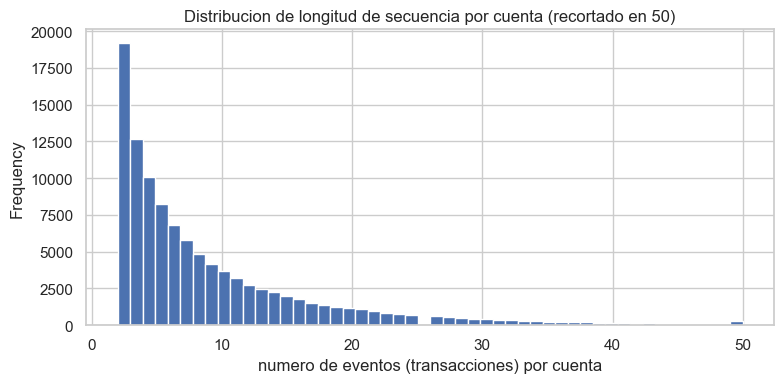


Longitud maxima de secuencia sugerida (percentil 95): 27
Decision: en el Componente 2, secuencias mas largas se truncan a los ultimos MAX_SEQ_LEN eventos 
(el comportamiento mas reciente es el mas relevante para una alerta); secuencias mas cortas se rellenan (padding) con mascara.


In [17]:
seq_lengths = events.groupby("account").size()
print(seq_lengths.describe())
for p in [50, 75, 90, 95, 99]:
    print(f"percentil {p}: {np.percentile(seq_lengths, p):.0f}")

fig, ax = plt.subplots(figsize=(8, 4))
seq_lengths.clip(upper=50).plot(kind="hist", bins=50, ax=ax, color="#4C72B0")
ax.set_title("Distribucion de longitud de secuencia por cuenta (recortado en 50)")
ax.set_xlabel("numero de eventos (transacciones) por cuenta")
plt.tight_layout()
plt.show()

MAX_SEQ_LEN = int(np.percentile(seq_lengths, 95))
print(f"\nLongitud maxima de secuencia sugerida (percentil 95): {MAX_SEQ_LEN}")
print("Decision: en el Componente 2, secuencias mas largas se truncan a los ultimos MAX_SEQ_LEN eventos ")
print("(el comportamiento mas reciente es el mas relevante para una alerta); secuencias mas cortas se rellenan (padding) con mascara.")

### 6.2 Proporcion de casos positivos y negativos

In [18]:
print("Proporcion global de cuentas (secuencias) sospechosas vs normales:")
print(account_labels["has_fraud"].value_counts(normalize=True))
print()
print("Por split:")
print(account_labels.groupby("split")["has_fraud"].value_counts(normalize=True).unstack())

Proporcion global de cuentas (secuencias) sospechosas vs normales:
has_fraud
0    0.947607
1    0.052393
Name: proportion, dtype: float64

Por split:
has_fraud         0         1
split                        
test       0.947568  0.052432
train      0.947611  0.052389
val        0.947628  0.052372


### 6.3 Ejemplos visualizados: secuencias normales vs. sospechosas

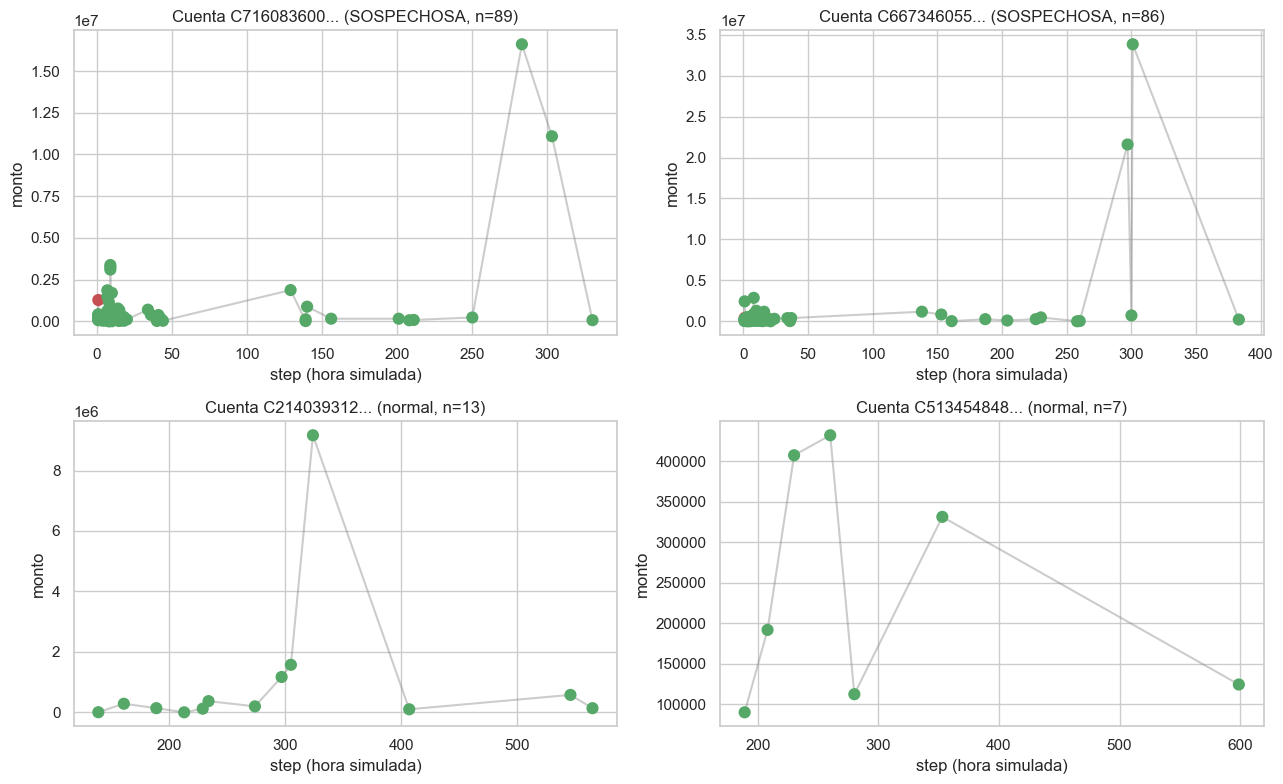

Rojo = transaccion marcada isFraud=1. Azul = evento saliente. Verde = evento entrante.


In [19]:
def plot_account_sequence(ax, account_id, label):
    seq = events[events["account"] == account_id].sort_values("step")
    colors = np.where(seq["isFraud"] == 1, "#C44E52", np.where(seq["direction"] == 1, "#55A868", "#4C72B0"))
    ax.scatter(seq["step"], seq["amount"], c=colors, s=60, zorder=3)
    ax.plot(seq["step"], seq["amount"], color="gray", alpha=0.4, zorder=1)
    ax.set_title(f"Cuenta {account_id[:10]}... ({label}, n={len(seq)})")
    ax.set_xlabel("step (hora simulada)")
    ax.set_ylabel("monto")

fraud_examples = account_labels[(account_labels["has_fraud"] == 1)].merge(
    seq_lengths.rename("n"), left_on="account", right_index=True
).sort_values("n", ascending=False).head(2)

normal_examples = account_labels[(account_labels["has_fraud"] == 0)].merge(
    seq_lengths.rename("n"), left_on="account", right_index=True
)
normal_examples = normal_examples[normal_examples["n"].between(5, 15)].sample(2, random_state=SEED)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
plot_account_sequence(axes[0, 0], fraud_examples.iloc[0]["account"], "SOSPECHOSA")
plot_account_sequence(axes[0, 1], fraud_examples.iloc[1]["account"], "SOSPECHOSA")
plot_account_sequence(axes[1, 0], normal_examples.iloc[0]["account"], "normal")
plot_account_sequence(axes[1, 1], normal_examples.iloc[1]["account"], "normal")
plt.tight_layout()
plt.savefig(DATA_PROCESSED / "ejemplos_secuencias.png", dpi=120)
plt.show()

print("Rojo = transaccion marcada isFraud=1. Azul = evento saliente. Verde = evento entrante.")

## 7. Resumen para el Componente 2

Artefactos guardados en data/processed/:
- account_events.parquet: una fila por evento, con account para agrupar y step para ordenar.
- account_labels_splits.parquet: una fila por cuenta, con has_fraud y split.

El Componente 2 agrupa account_events por account, ordena por step, trunca a MAX_SEQ_LEN, y separa cuentas has_fraud == 0 del split de train para la Etapa A.